Script started successfully

=== Regression Results ===
Intercept (β0): 17.3977
Slope - Agricultural Expansion (β1): 0.5393
Slope - Cattle Density (β2): 9.8340
R² Score: 0.7785


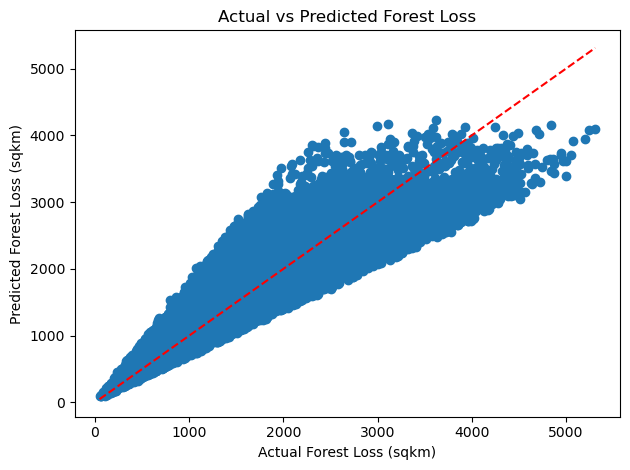

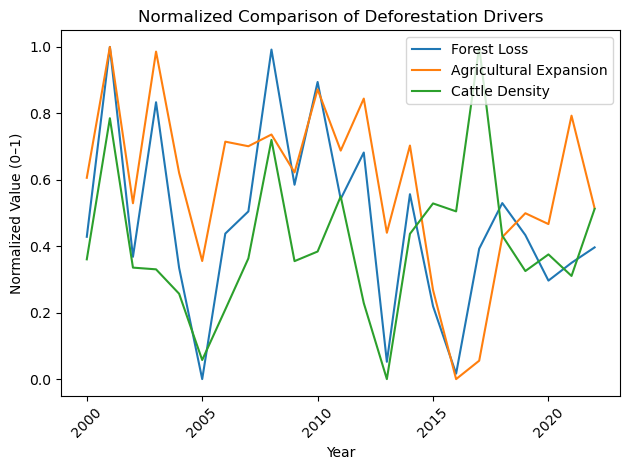


=== Correlation Matrix ===
                             forest_loss_sqkm  agricultural_expansion_sqkm  \
forest_loss_sqkm                     1.000000                     0.798167   
agricultural_expansion_sqkm          0.798167                     1.000000   
cattle_density                       0.371293                    -0.005989   

                             cattle_density  
forest_loss_sqkm                   0.371293  
agricultural_expansion_sqkm       -0.005989  
cattle_density                     1.000000  


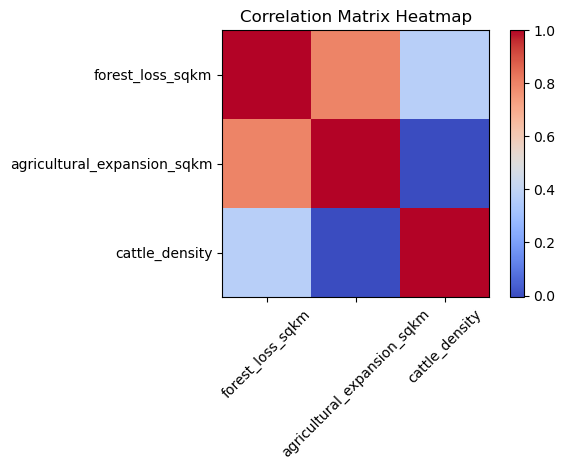


Script completed successfully


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

print("Script started successfully")

# -------------------------------------------------
# LOAD DATA
# -------------------------------------------------
df = pd.read_excel("deforestation_cleaned.xlsx")

# -------------------------------------------------
# REGRESSION MODEL
# -------------------------------------------------
X = df[["agricultural_expansion_sqkm", "cattle_density"]]
Y = df["forest_loss_sqkm"]

model = LinearRegression()
model.fit(X, Y)

df["predicted_forest_loss"] = model.predict(X)

# -------------------------------------------------
# PRINT REGRESSION RESULTS
# -------------------------------------------------
print("\n=== Regression Results ===")
print(f"Intercept (β0): {model.intercept_:.4f}")
print(f"Slope - Agricultural Expansion (β1): {model.coef_[0]:.4f}")
print(f"Slope - Cattle Density (β2): {model.coef_[1]:.4f}")
print(f"R² Score: {model.score(X, Y):.4f}")

# =================================================
# GRAPH 1: ACTUAL vs PREDICTED
# =================================================
plt.figure()

plt.scatter(df["forest_loss_sqkm"], df["predicted_forest_loss"])

plt.plot(
    [df["forest_loss_sqkm"].min(), df["forest_loss_sqkm"].max()],
    [df["forest_loss_sqkm"].min(), df["forest_loss_sqkm"].max()],
    "r--"
)

plt.xlabel("Actual Forest Loss (sqkm)")
plt.ylabel("Predicted Forest Loss (sqkm)")
plt.title("Actual vs Predicted Forest Loss")
plt.tight_layout()
plt.show()

# =================================================
# GRAPH 2: NORMALIZED LINE GRAPH (0–1 SCALE)
# =================================================

# Group yearly averages
yearly_data = df.groupby("year").mean(numeric_only=True)

forest = yearly_data["forest_loss_sqkm"]
agriculture = yearly_data["agricultural_expansion_sqkm"]
cattle = yearly_data["cattle_density"]

# Min-Max Normalization
forest_norm = (forest - forest.min()) / (forest.max() - forest.min())
agriculture_norm = (agriculture - agriculture.min()) / (agriculture.max() - agriculture.min())
cattle_norm = (cattle - cattle.min()) / (cattle.max() - cattle.min())

plt.figure()

plt.plot(yearly_data.index, forest_norm, label="Forest Loss")
plt.plot(yearly_data.index, agriculture_norm, label="Agricultural Expansion")
plt.plot(yearly_data.index, cattle_norm, label="Cattle Density")

plt.xlabel("Year")
plt.ylabel("Normalized Value (0–1)")
plt.title("Normalized Comparison of Deforestation Drivers")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =================================================
# CORRELATION MATRIX
# =================================================
print("\n=== Correlation Matrix ===")

correlation_matrix = df[[
    "forest_loss_sqkm",
    "agricultural_expansion_sqkm",
    "cattle_density"
]].corr()

print(correlation_matrix)

# Heatmap
plt.figure()
plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="none")
plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

print("\nScript completed successfully")